# Bacon–Shor dedicated SE / generic SE 对照

**[DEMO]** — 使用已封装的 BaconShorCode、两种 extraction blocks 和 MemoryExperiment。

默认版本固定 X 左→右、Z 上→下（row-index 图）。Generic 版本保留为显式选项。
二者都是四层 CNOT，signed measurement instrument 相同，但实际 Z 层顺序不同。
所有 detectors 和 observables 均由 LightStim Builder/Tracker 生成。


In [1]:
import sys, json
from pathlib import Path
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "lightstim").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from lightstim.ir.qec_system import QECSystem
from lightstim.protocols.memory import MemoryExperiment
from lightstim.qec_code.bacon_shor import BaconShorCode, BaconShorCodeExtractionBlock
from lightstim.qec_code.generic_css import GenericCSSGaugeExtractionBlock
from IPython.display import Image, SVG, display
import pandas as pd
ASSETS = ROOT / "playground/subsystem/bacon_shor_schedule/results/2026-09-06"
system = QECSystem()
system.add_patch(BaconShorCode(distance=3), name="bs")
dedicated = BaconShorCodeExtractionBlock(system)
generic = GenericCSSGaugeExtractionBlock(system)
print("CNOT depth:", dedicated.cnot_depth, generic.cnot_depth)
assert all(generic.circuit.has_flow(f, unsigned=False) for f in dedicated.circuit.flow_generators())
assert all(dedicated.circuit.has_flow(f, unsigned=False) for f in generic.circuit.flow_generators())

CNOT depth: 4 4


## 四层配对：看实际的全局 qubit indices

上排为新的默认版本，下排为 generic；箭头为 CNOT control → target。

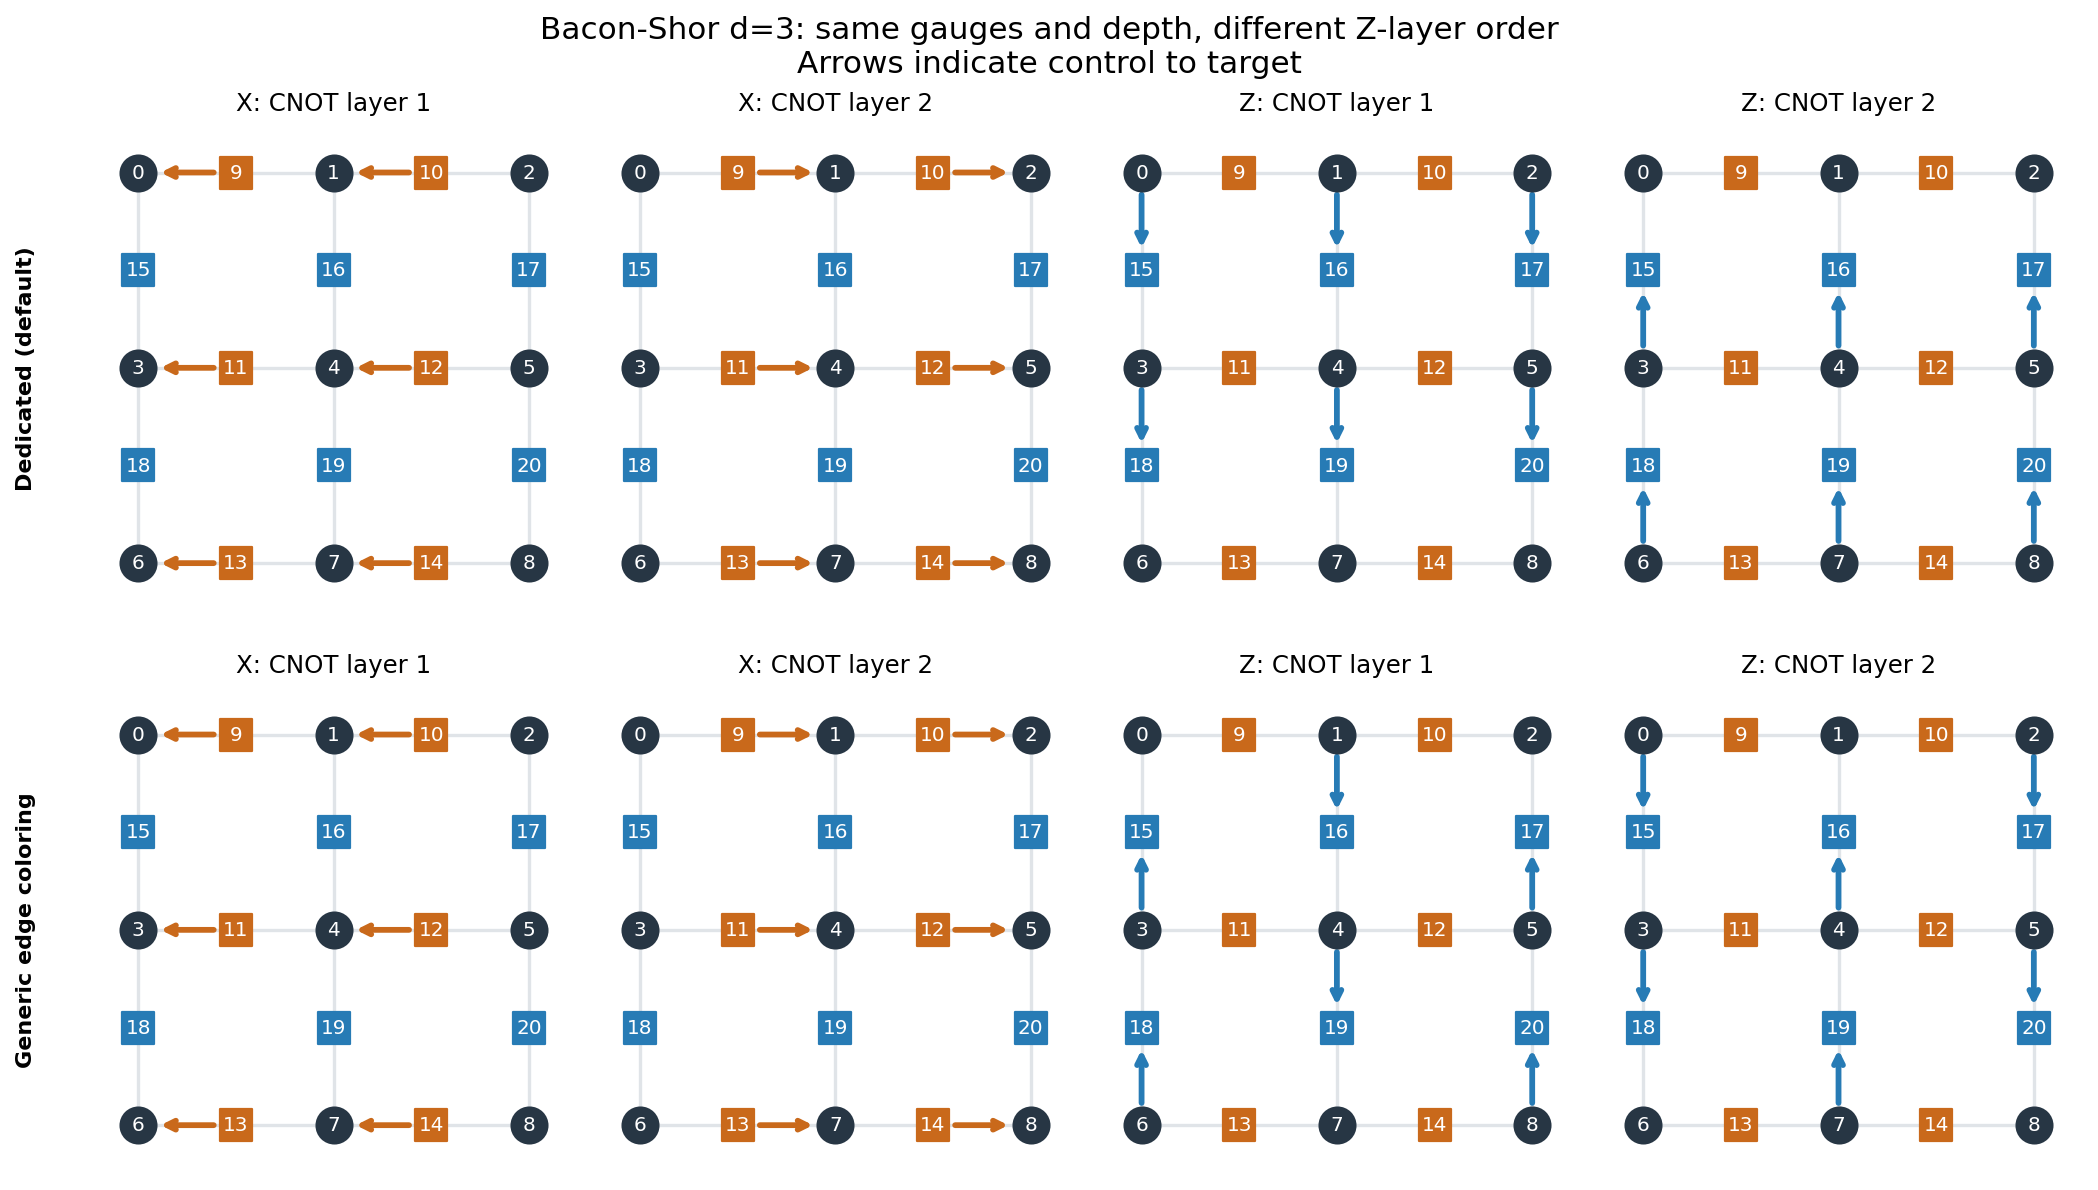

In [2]:
display(Image(filename=str(ASSETS / "schedule_comparison.png")))

## 默认 SE 的实际 Stim 指令

不含 noise 和 detectors；每个 basis block 有独立 reset 和 terminal measurement。

In [3]:
print(dedicated.circuit)

RX 9 10 11 12 13 14
TICK[SE_start]
CX 9 0 10 1 11 3 12 4 13 6 14 7
TICK
CX 9 1 10 2 11 4 12 5 13 7 14 8
TICK
MX 9 10 11 12 13 14
TICK
R 15 16 17 18 19 20
TICK[SE_start]
CX 0 15 1 16 2 17 3 18 4 19 5 20
TICK
CX 3 15 4 16 5 17 6 18 7 19 8 20
TICK
M 15 16 17 18 19 20


## 用原生 MemoryExperiment 生成 detectors

完整的两轮 Z-memory，包含初始化和最终 data readout。

In [4]:
memory = MemoryExperiment(qec_patch=BaconShorCode(distance=3), basis="Z", rounds=2)
assert memory.block_class is BaconShorCodeExtractionBlock
circuit = memory.build()
assert not circuit.compile_detector_sampler(seed=70).sample(256, append_observables=True).any()
print("qubits / measurements / detectors / observables:", circuit.num_qubits, circuit.num_measurements, circuit.num_detectors, circuit.num_observables)
display(SVG(filename=str(ASSETS / "d3_two_rounds_dedicated_detslice.svg")))

qubits / measurements / detectors / observables: 21 33 12 1


## 已完成的 distance / detector / decoding 核对

d=3,5,7,9；X/Z memories；每次 d 个 XZ pairs。兩种调度的 affine detector spaces 相同，logical observables 模 detectors 相同。
32 个 distance cases（两种调度、两种 memory basis、两种 readout fault models）都有相等的上下界 d。

下表的 MWPM 使用 Z detectors。p=0.001：reset/ancilla readout flips、CX depolarization，无 idle noise，末端 data readout 理想。
每点固定 100 万 shots，计数是整个 memory shot 的 LER。测量 instrument 相同不代表 noisy LER 必须相同。


,schedule,d,rounds,shots,errors,ler,ci_low,ci_high
0,dedicated,3,3,1000000,532,0.000532,0.000488,0.000579
1,generic,3,3,1000000,525,0.000525,0.000481,0.000572
2,dedicated,5,5,1000000,198,0.000198,0.000171,0.000228
3,generic,5,5,1000000,206,0.000206,0.000179,0.000236
4,dedicated,7,7,1000000,99,0.000099,0.000080,0.000121
5,generic,7,7,1000000,133,0.000133,0.000111,0.000158
6,dedicated,9,9,1000000,53,0.000053,0.000040,0.000069
7,generic,9,9,1000000,76,0.000076,0.000060,0.000095


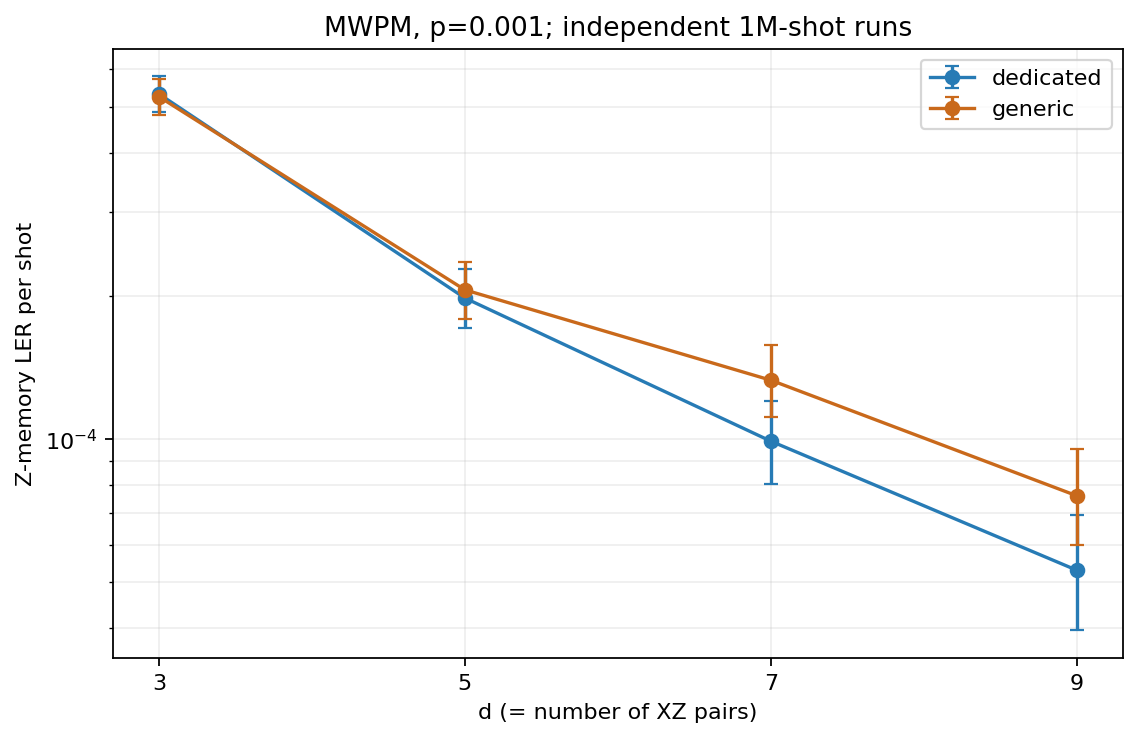

In [5]:
results = json.loads((ASSETS / "summary.json").read_text())
assert all(r["lower_bound"] == r["upper_bound"] == r["d"] for r in results["distances"])
display(pd.read_csv(ASSETS / "mwpm.csv"))
display(Image(filename=str(ASSETS / "mwpm_comparison.png")))

## 显式选择 generic

```python
generic_memory = MemoryExperiment(
    qec_patch=BaconShorCode(distance=3),
    extraction_block_class=GenericCSSGaugeExtractionBlock,
    basis="Z", rounds=3,
).build()
```

Source: `lightstim/qec_code/bacon_shor/SE_block.py`。完整实验脚本和原始数据在 `playground/subsystem/bacon_shor_schedule/`。
